In [34]:
import pandas as pd
import numpy as np
import seaborn as sns
from plotnine import *

titanic = sns.load_dataset('titanic')

-----

# Dtypes

In [10]:
users_dt = pd.read_csv('../Datasets/Exercise2_datasets/BX-Users.csv')
users_dt.dtypes

User-ID       int64
Location     object
Age         float64
dtype: object

-------

# How To Filter

use `.loc` instead of `titanic[~ind, 'age']`

In [4]:
ind = np.isnan(titanic['age'])
titanic.loc[~ind, 'age'].values.mean()

np.float64(29.69911764705882)

In [39]:
books_dt = pd.read_csv('../Datasets/Exercise2_datasets/BX-Books.csv') 
books_dt = books_dt.drop(columns = ['Image-URL-S', 'Image-URL-M', 'Image-URL-L']) # önemsiz

book_df_2 = books_dt[books_dt['Year-Of-Publication'].isin(range(1900,2020))]
book_df_2.head()

books_dt[books_dt['Year-Of-Publication'].isin(range(1900,2020))][['ISBN','Book-Title']]

,ISBN,Book-Title
0,0195153448,Classical Mythology
1,0002005018,Clara Callan
2,0060973129,Decision in Normandy
3,0374157065,Flu: The Story of the Great Influenza Pandemic...
4,0393045218,The Mummies of Urumchi
...,...,...
262495,0441297528,The Golden Naginata
262496,0441792642,Sensei II: Sword Master
262497,0448164884,More Stan Fishchler's Sports Stumpers
262498,0451520521,Babbitt


----

# idxmin - Argmin

In [5]:
tips = sns.load_dataset('tips')
tips['total_bill'].idxmin()

67

------

# Categories

* `nunique()` → how many values actually appear

* `dtype.categories` → how many values are allowed by the type

<u>return_counts = True</u>

In [84]:
b = tips['day']
unique_values, counts = np.unique(b, return_counts= True)

print('Values:', unique_values)
print('Counts:', counts)

b.dtype.categories

Values: ['Fri' 'Sat' 'Sun' 'Thur']
Counts: [19 87 76 62]


Index(['Thur', 'Fri', 'Sat', 'Sun'], dtype='object')

------------
# .tolist()

In [55]:
import numpy as np
import pandas as pd

n = 100

id = ['ID' + str(i) for i in range(n)]
val = np.random.normal(loc = 0, scale = 1, size = n)

dummy_df = pd.DataFrame({
    'id' : id,
    'val' : val
})

display(dummy_df.head())

names = dummy_df.sort_values(by = 'val')['id'].tolist()

names[0:3]

,id,val
0,ID0,1.139607
1,ID1,2.463001
2,ID2,-0.785810
3,ID3,2.427602
4,ID4,0.440116


['ID11', 'ID80', 'ID51']

-------

# Drop 

## Column

In [16]:
books_dt = pd.read_csv('../Datasets/Exercise2_datasets/BX-Books.csv')

books_dt = books_dt.drop(columns = ['Image-URL-S', 'Image-URL-M', 'Image-URL-L'])

## NA

In [42]:
np.random.seed(0)

df = pd.DataFrame({
    'age': [23, np.nan, 35, np.nan, 42],
    'fare': [100, 200, np.nan, 150, np.nan],
    'sex': ['male', 'female', 'female', 'male', 'female']
})

df.head()

,age,fare,sex
0,23.0,100.0,male
1,NaN,200.0,female
2,35.0,NaN,female
3,NaN,150.0,male
4,42.0,NaN,female


In [ ]:
df.dropna(subset = ['fare', 'age'], how = 'all') # any

,age,fare,sex
0,23.0,100.0,male
1,NaN,200.0,female
2,35.0,NaN,female
3,NaN,150.0,male
4,42.0,NaN,female


how = 'all' makes sure that only rows are dropped where both, fare and age are none

------

# Unique

In [21]:
books_dt = pd.read_csv('../Datasets/Exercise2_datasets/BX-Books.csv')

books_dt['Book-Author'].nunique()

98538

In [25]:
tips = sns.load_dataset('tips')

b = tips['time']
unique_values, counts = np.unique(b, return_counts= True)

print('Values:', unique_values)
print('Counts:', counts)

Values: ['Dinner' 'Lunch']
Counts: [176  68]


---------

# Replace

In [38]:
import numpy as np
import pandas as pd

num = np.random.random_integers(low = 1, high=2, size= 10)

replace_df = pd.DataFrame({
    'student' : num
})

replace_df['studentReplaced'] = replace_df['student'].replace({
    1:'Male',
    2:'Female'
})

replace_df

/var/folders/nn/rd9y9hfx7qz4tk9cjwqs2xrh0000gn/T/ipykernel_11801/2343721341.py:4: DeprecationWarning: This function is deprecated. Please call randint(1, 2 + 1) instead


,student,studentReplaced
0,2,Female
1,2,Female
2,2,Female
3,1,Male
4,2,Female
5,2,Female
6,2,Female
7,1,Male
8,1,Male
9,2,Female


---------

# Common - mode

the most common rating value larger than 0

In [22]:
ratings_dt = pd.read_csv('../Datasets/Exercise2_datasets/BX-Book-Ratings.csv')

ratings_dt[ ratings_dt['Book-Rating'] != 0]['Book-Rating'].mode()

0    8
Name: Book-Rating, dtype: int64

-----

# Size 

size()

In [ ]:
star_wars_df = pd.read_csv('../Datasets/Exercise2_datasets/star_wars_character_dataset.csv',
                    usecols = ["name", "height", "mass", "birth_year", "sex", "homeworld", "species"])

star_wars_df = star_wars_df.rename(columns = {'birth_year': 'age'})

star_wars_df[star_wars_df['height'] > 200].groupby('species').size()

species
Gungan      2
Human       1
Kaleesh     1
Kaminoan    2
Pau'an      1
Quermian    1
Wookiee     2
dtype: int64

size

In [26]:
tips = sns.load_dataset('tips')

tips.size

1708

------

# pd.Crosstab

contingency

In [52]:
import seaborn as sns
import numpy as np
import pandas as pd

mpg = sns.load_dataset('mpg').dropna()

cont_tbl = pd.crosstab(
    mpg['cylinders'] > 4,
    mpg['horsepower'] > 150
)

cont_tbl

horsepower,False,True
cylinders,,
False,203,0
True,144,45


-------------

# Rename Column

In [27]:
star_wars_df = pd.read_csv('../Datasets/Exercise2_datasets/star_wars_character_dataset.csv',
                    usecols = ["name", "height", "mass", "birth_year", "sex", "homeworld", "species"])

star_wars_df = star_wars_df.rename(columns = {'birth_year': 'age'})
star_wars_df.head()

,name,height,mass,age,sex,homeworld,species
0,Luke Skywalker,172.0,77.0,19.0,male,Tatooine,Human
1,C-3PO,167.0,75.0,112.0,none,Tatooine,Droid
2,R2-D2,96.0,32.0,33.0,none,Naboo,Droid
3,Darth Vader,202.0,136.0,41.9,male,Tatooine,Human
4,Leia Organa,150.0,49.0,19.0,female,Alderaan,Human


---------

# np.where()

In [67]:
np.random.seed(123)
random_number = np.random.normal(loc = 0, scale = 10, size = 100)

whereDf = pd.DataFrame({'nums':random_number})

whereDf['greaterThan0'] = np.where(whereDf['nums'] > 0, 1,0)
whereDf.head()


,nums,greaterThan0
0,-10.856306,0
1,9.973454,1
2,2.829785,1
3,-15.062947,0
4,-5.786003,0


------

# Transform

/var/folders/nn/rd9y9hfx7qz4tk9cjwqs2xrh0000gn/T/ipykernel_92911/873672501.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


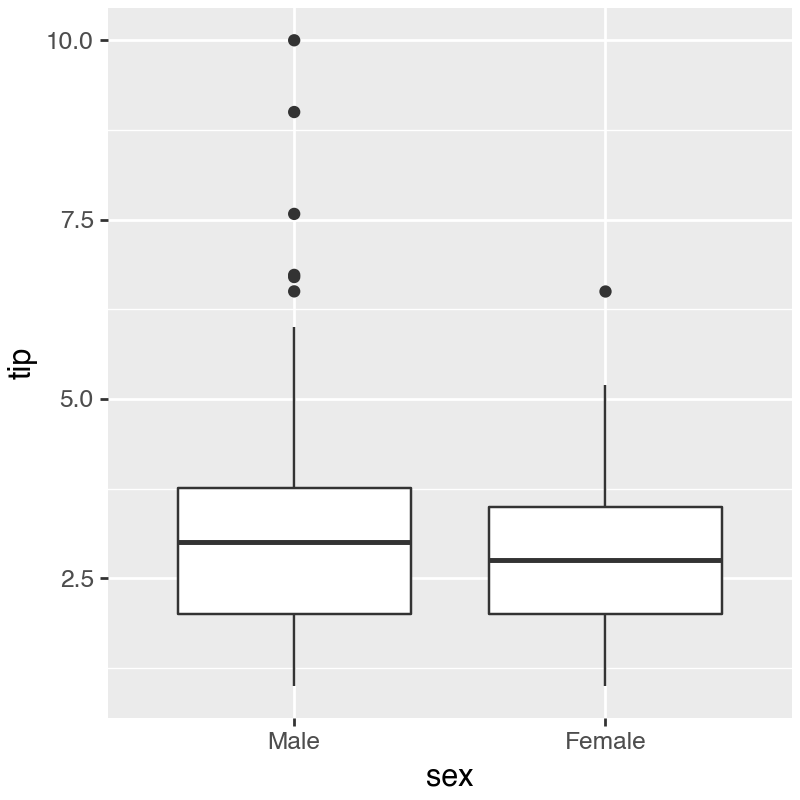

In [36]:
dt = sns.load_dataset('tips')
dt['sex_av'] = dt.groupby('sex')['tip'].transform('mean')

dt['dist_avg'] = dt['tip'] - dt['sex_av']

(
    ggplot(dt, aes('sex', 'tip')) + 
    geom_boxplot() +
    theme(figure_size= (4,4))
)

--------

# Union

concat 

In [45]:
import glob

files = glob.glob('../Datasets/Exercise2_datasets/extdata 3/baby-names/*.csv')

dfs = []

for i in range(len(files)):
    df = pd.read_csv(files[i])
    df['year'] = files[i].split('/')[-1].split('.')[0]
    dfs.append(df)

df = pd.concat(dfs, ignore_index= True)  ## Important part
df.head()

,name,percent,year
0,Jacob,0.016514,2000
1,Michael,0.015346,2000
2,Matthew,0.013695,2000
3,Joshua,0.013194,2000
4,Christopher,0.011990,2000


# Merge

In [56]:
import pandas as pd

students = pd.DataFrame({
    'student_id': [1, 2, 3, 4],
    'name': ['Alice', 'Bob', 'Charlie', 'David']
})

scores = pd.DataFrame({
    'student_id': [1, 2, 4],
    'math_score': [85, 90, 78]
})

display(students.head(), scores.head())
pd.merge(students, scores, on='student_id', how='inner')

,student_id,name
0,1,Alice
1,2,Bob
2,3,Charlie
3,4,David


,student_id,math_score
0,1,85
1,2,90
2,4,78


,student_id,name,math_score
0,1,Alice,85
1,2,Bob,90
2,4,David,78


-------

# Draw Line

## stat_smooth(method = 'lm')

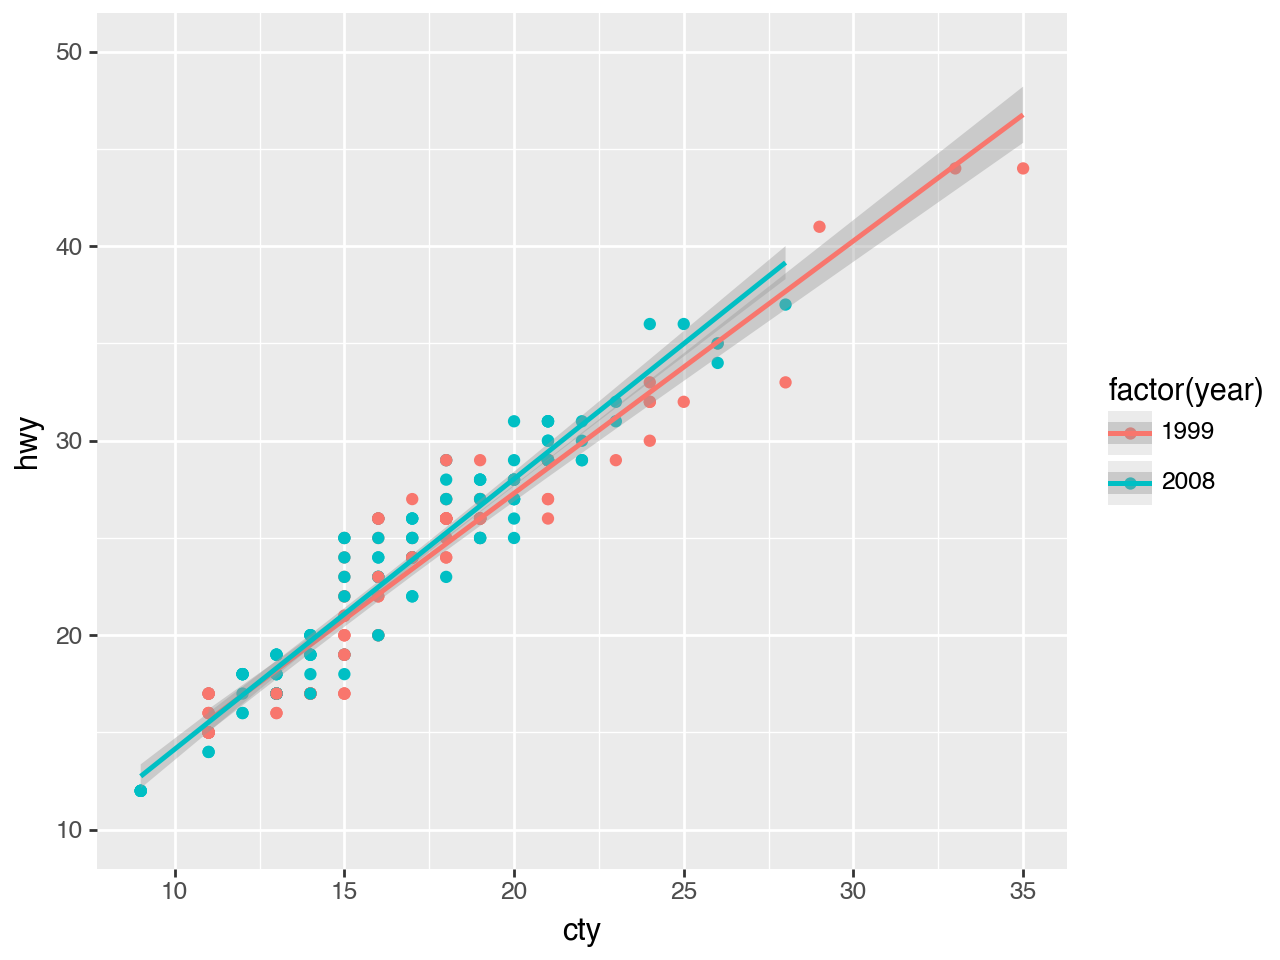

In [48]:
from plotnine.data import mpg

df = mpg[mpg['year'].isin([1999, 2008])][['cty','hwy', 'year']]
df['year'] = df['year'].astype('category')

(
    ggplot(df, aes(x = 'cty', y = 'hwy', color = 'year')) +
    geom_point() +
    stat_smooth(method = 'lm') +
    scale_y_continuous(limits=(10, 50)) + 
    labs(color = 'factor(year)')
)


## geom_jitter()

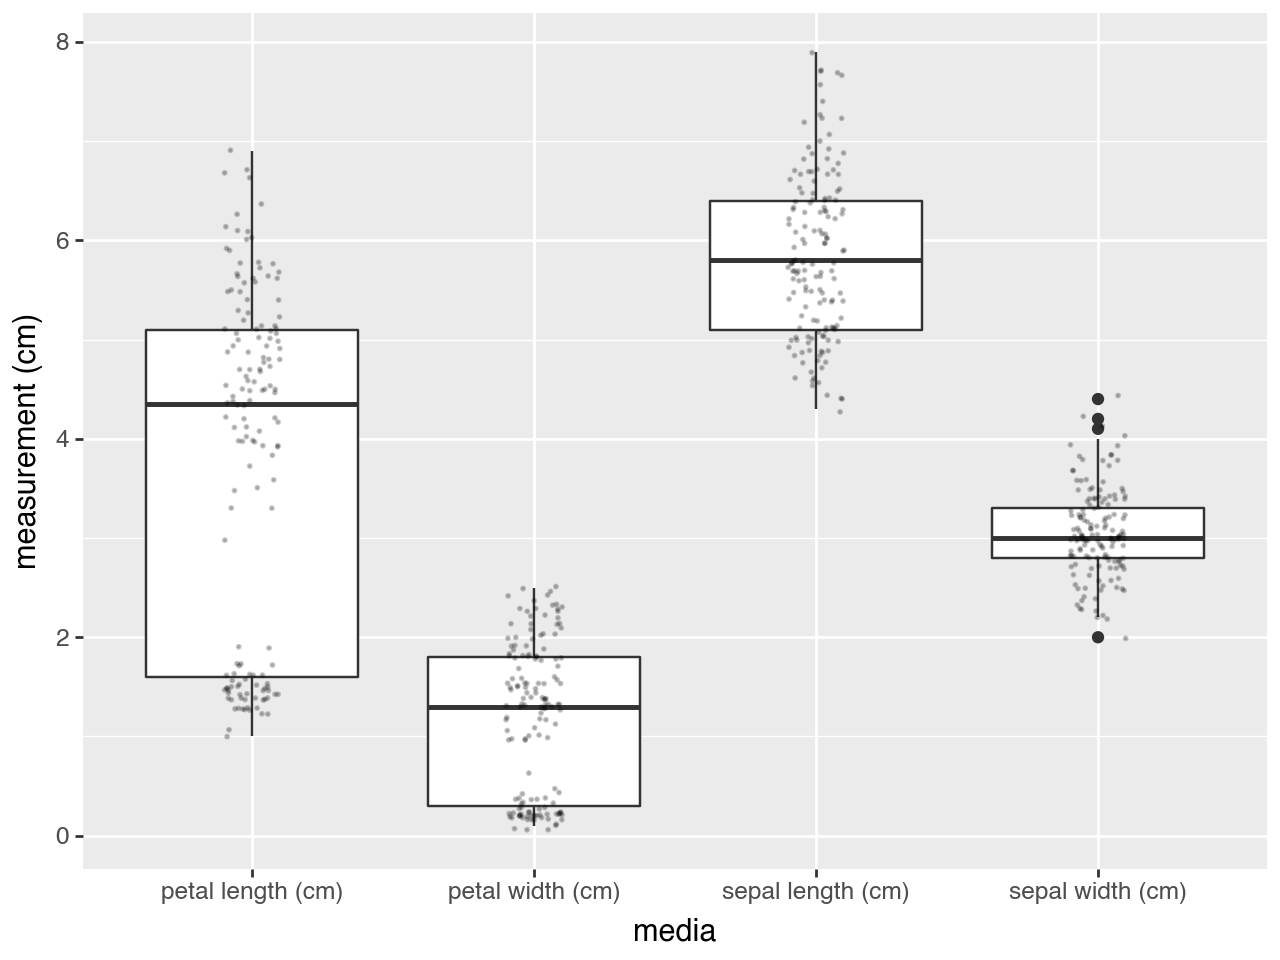

In [50]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)['frame']

iris['target'] = ['setosa' if s==0 else 'versicolor' if s==1 else 'virginica' \
for s in iris['target']]

iris_dist = iris.melt(id_vars= 'target', var_name= 'media', value_name= 'measurement (cm)')

(
    ggplot(iris_dist, aes(x = 'media', y = 'measurement (cm)'))+
    geom_boxplot() + 
    geom_jitter(width = 0.1, size = 0.2, alpha = 0.2)
)

## geom_violin()

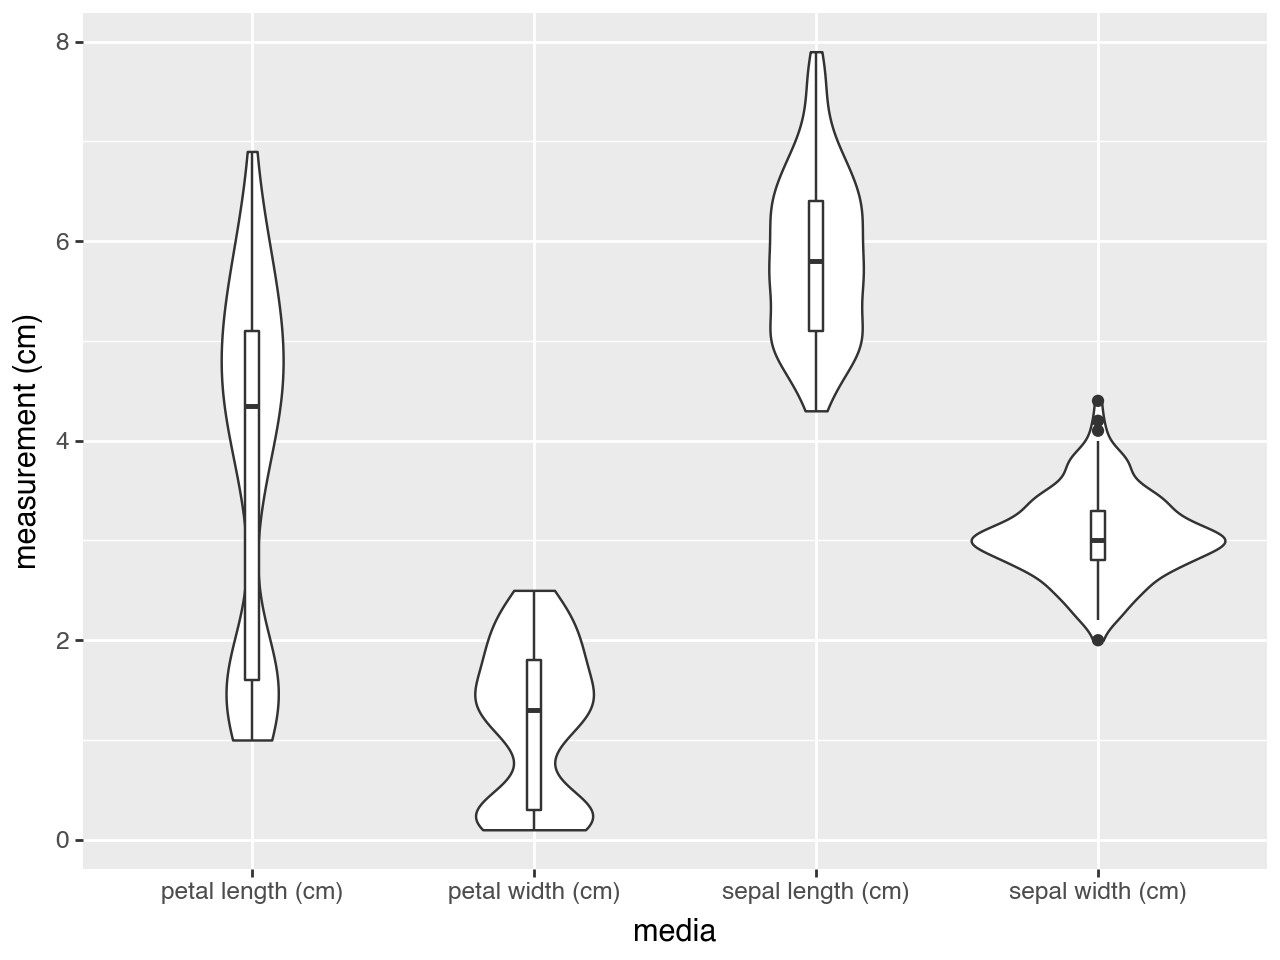

In [53]:
(
    ggplot(iris_dist, aes(x = 'media', y = 'measurement (cm)')) +
    geom_violin() + 
    geom_boxplot(width = 0.05) 
)

## geom_qq - QQ_plot

       

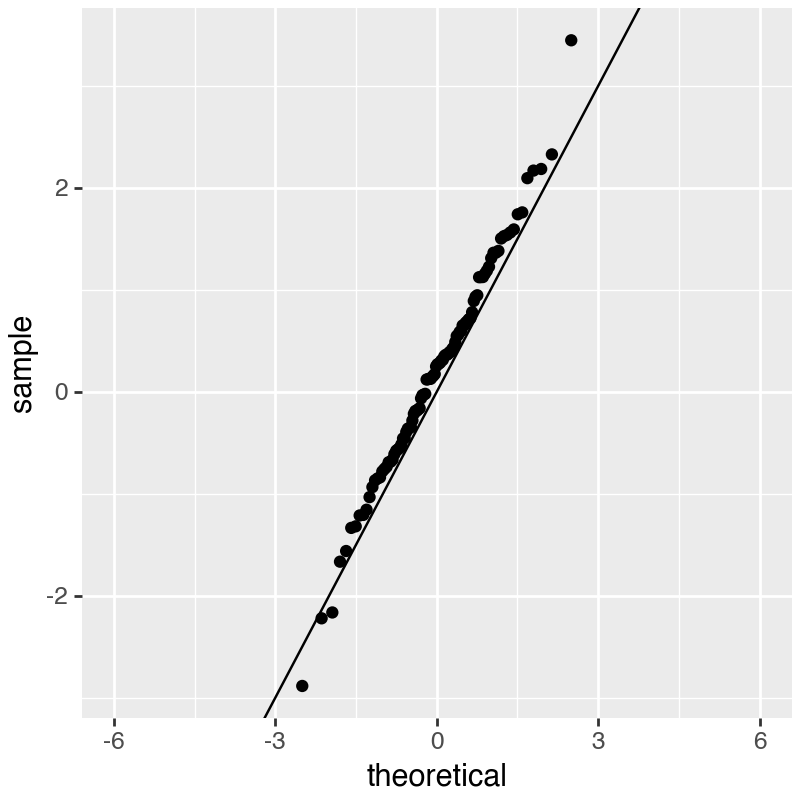

In [57]:
np.random.seed(525)

points = np.random.normal(loc = 0, scale = 1, size = 100)
dt = pd.DataFrame({'points':points})

(
    ggplot(dt, aes(sample = 'points')) +
    geom_qq() + 
    geom_abline(slope = 1, intercept = 0) + 
    xlim(-6,6) + 
    theme(figure_size=(4,4))
)

## geom_bin_2d()

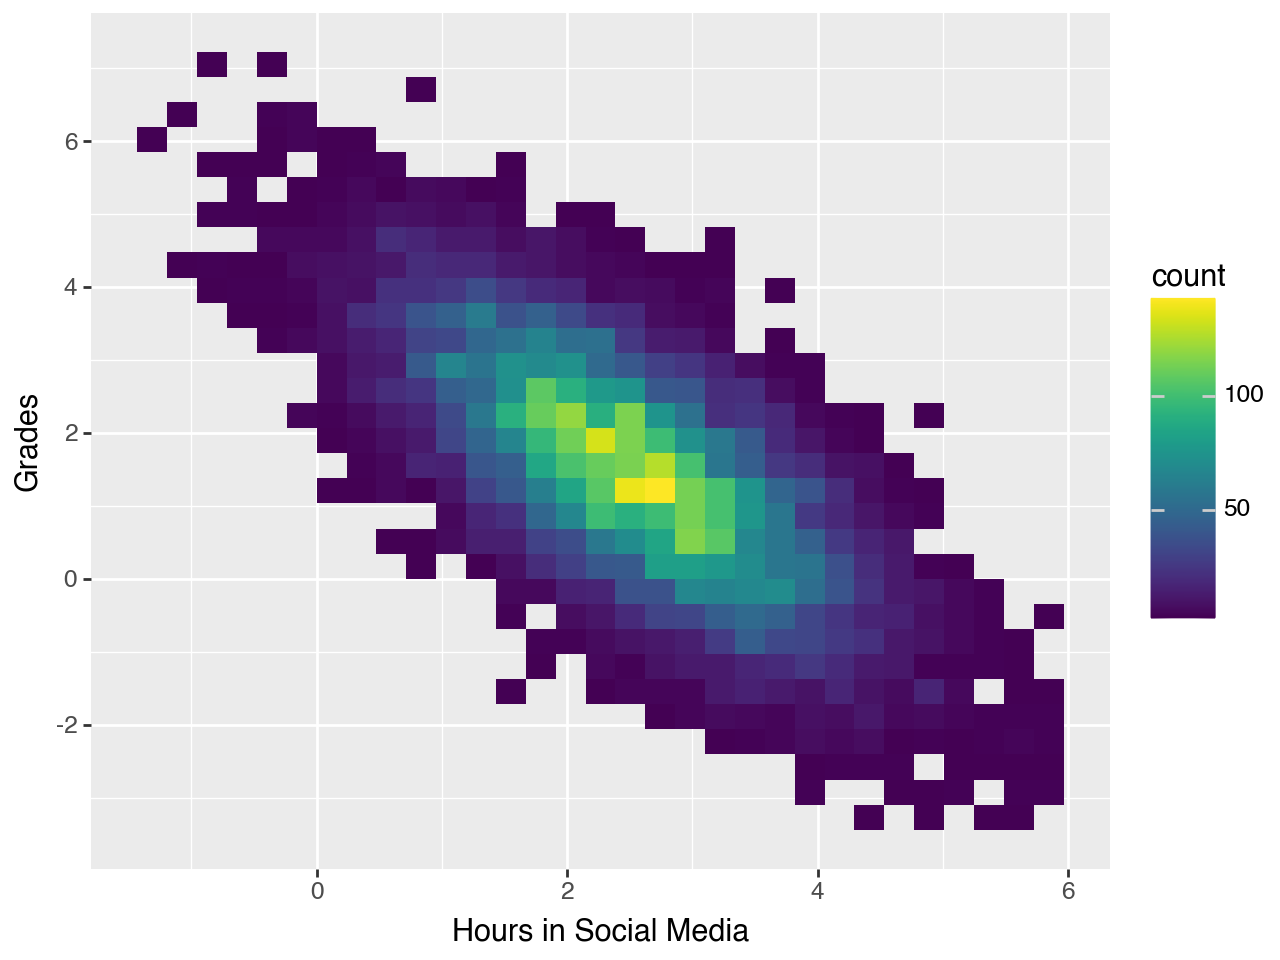

In [59]:
hours_in_social_media = np.random.normal(loc = 2.5, scale = 1, size = 10000)
grades = 4 - hours_in_social_media + np.random.normal(loc = 0, scale = 1, size = 10000)

grade_media = pd.DataFrame({
    'grades' : grades,
    'media_h': hours_in_social_media
})

(
    ggplot(grade_media, aes('media_h', 'grades')) +
    geom_bin_2d(bins = 30) +  
    labs(y = 'Grades', x = 'Hours in Social Media')
)

## geom_bar()

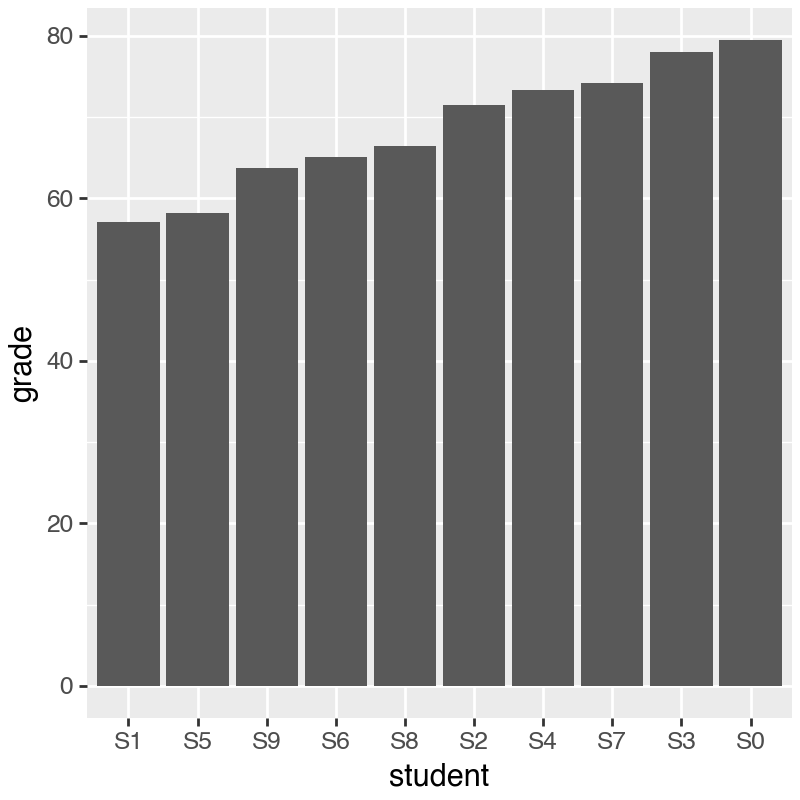

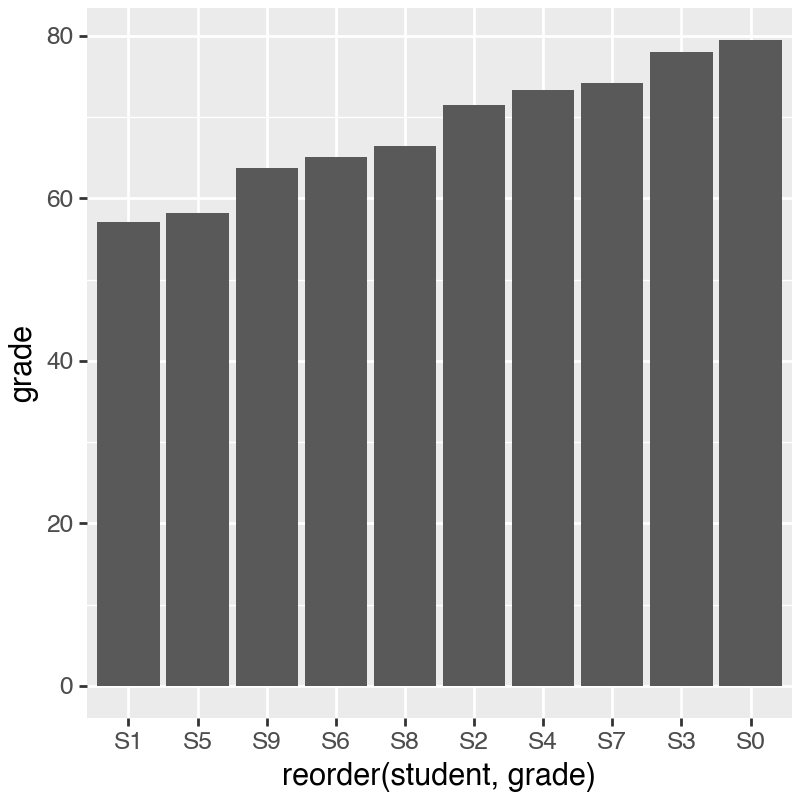

In [25]:
import numpy as np
import pandas as pd
from plotnine import *

np.random.seed(585)
n = 10

students = ['S' + str(i) for i in range(n)]
grades = np.random.normal(loc = 70, scale = 10, size = n)

scores_df = pd.DataFrame({
    'student' : students,
    'grade': grades
})

scores_df.sort_values(by = 'grade', inplace= True)
scores_df['student'] = pd.Categorical(
    scores_df['student'],
    categories=scores_df['student'],
    ordered=True
)

display(
(
    ggplot(scores_df, aes(x = 'student', y = 'grade')) +
    geom_bar(stat = 'identity') +
    theme(figure_size=(4,4))
)
)

display(
(
    ggplot(scores_df, aes(x = 'reorder(student, grade)', y = 'grade')) +
    geom_bar(stat = 'identity')+
    theme(figure_size= (4,4))
)
)

### geom_bar(position = fill)

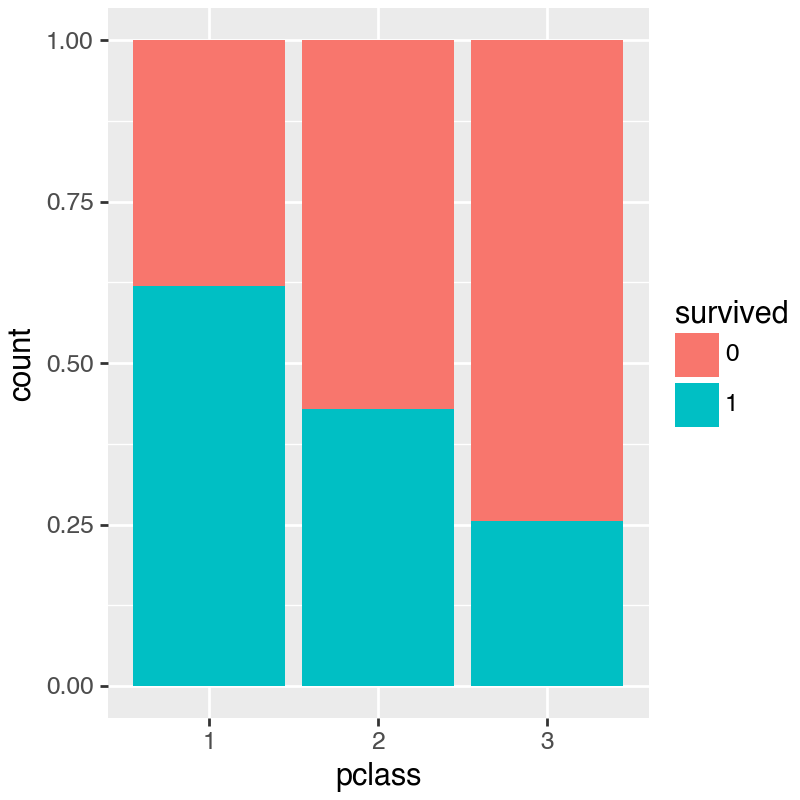

In [28]:
import numpy as np
import pandas as pd
from plotnine import *

titanic = pd.read_csv('../Datasets/Exercise2_datasets/exdata 6/titanic.csv')
titanic['survived'] = titanic['survived'].astype('category')
titanic['pclass'] = titanic['pclass'].astype('category')

(
    ggplot(titanic, aes(x = 'pclass', fill = 'survived')) + 
    geom_bar(position = 'fill') + 
    theme(figure_size=(4,4))
)

## geom_col()

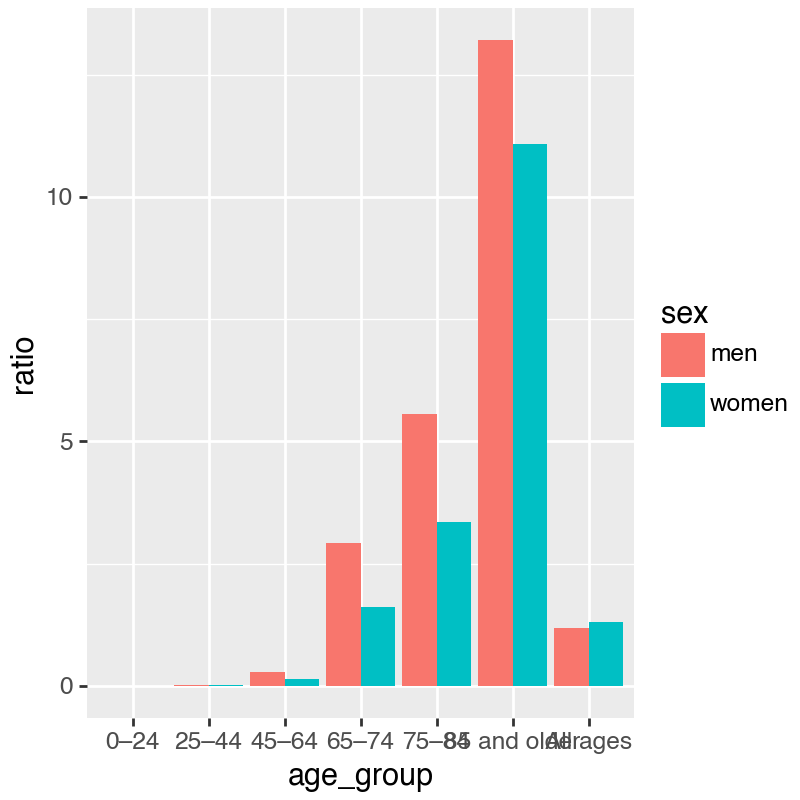

In [ ]:

fatalitiy_df = pd.read_csv('../Datasets/Exercise2_datasets/exdata 6/belgium_infection_fatality_rate_june2020.csv')
fatalitiy_df['age_group'] = fatalitiy_df['age_group'].astype('category')

fatalitiy_df = fatalitiy_df.melt(id_vars= 'age_group', var_name= 'sex', value_name= 'ratio')

(
    ggplot(fatalitiy_df, aes(x = 'age_group',y = 'ratio', fill = 'sex')) + 
    geom_col(position = 'dodge') +
    theme(figure_size=(4,4))
)

## geom_vline()

xintercept

/opt/anaconda3/lib/python3.13/site-packages/plotnine/stats/stat_bin.py:112: PlotnineWarning: 'stat_bin()' using 'bins = 24'. Pick better value with 'binwidth'.


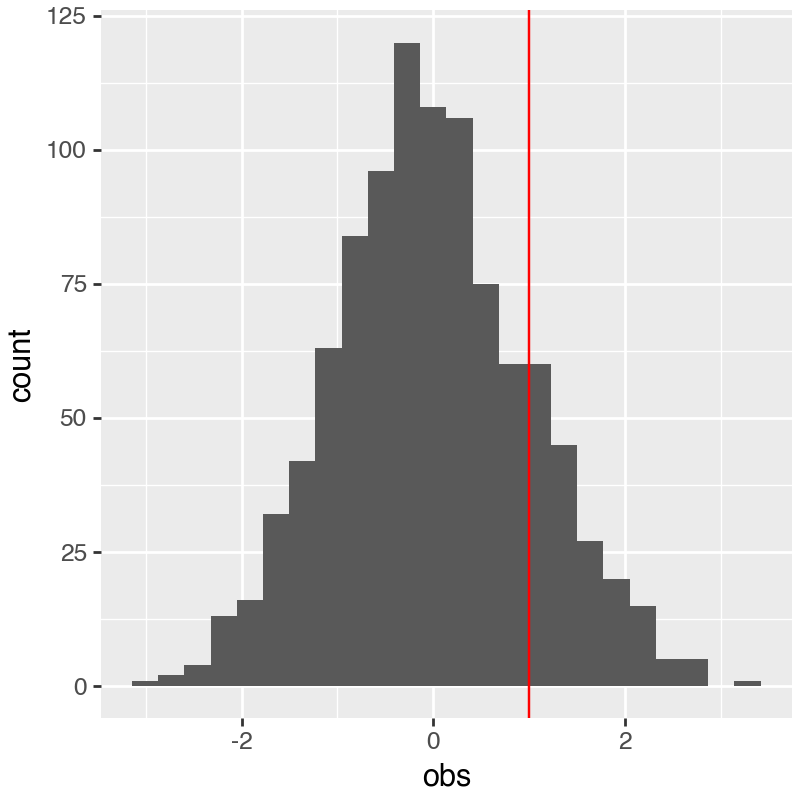

In [40]:
import numpy as np
import pandas as pd

observations = np.random.normal(loc = 0, scale = 1, size = 1000)
vline_df = pd.DataFrame({'obs':observations})

(
    ggplot(vline_df, aes('obs')) +
    geom_histogram() + 
    geom_vline(xintercept = 1, color = 'red') + 
    theme(figure_size=(4,4))  
)

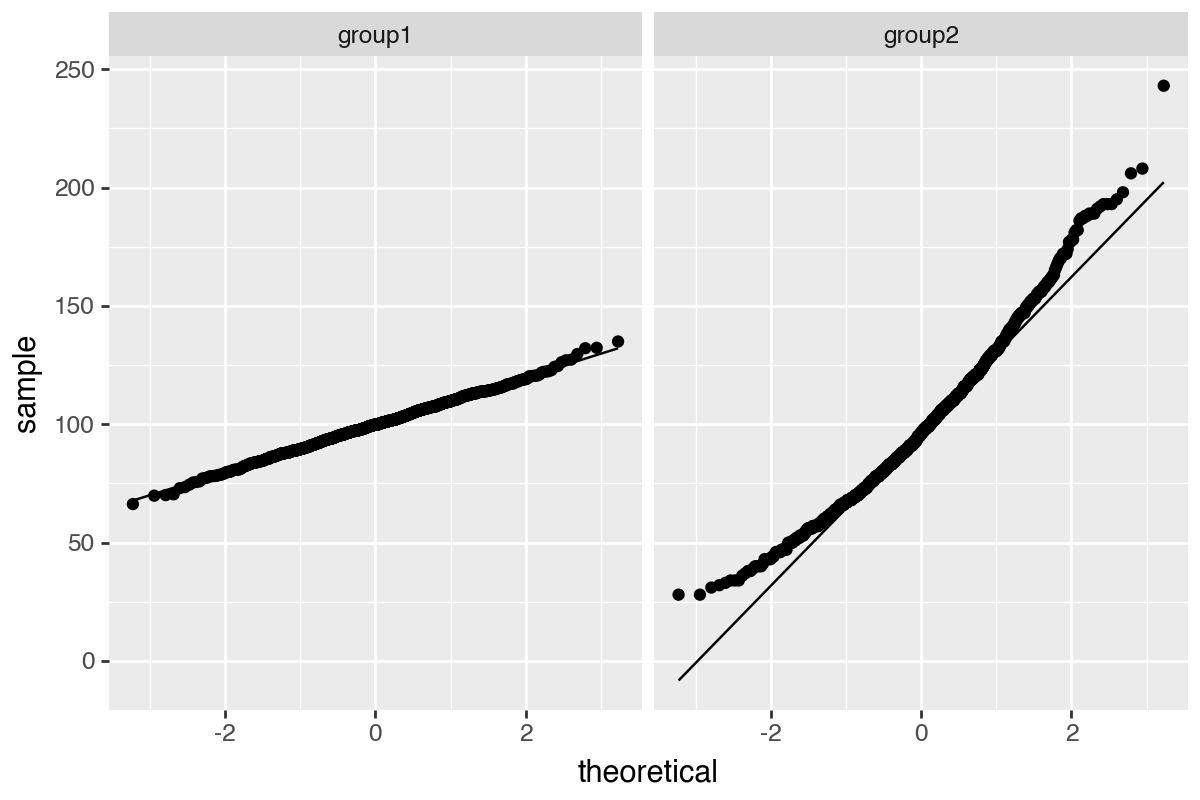

In [48]:
## QQ_line
import pandas as pd
import numpy as np

df = pd.read_csv('../Datasets/ExData8/stats-pitfalls.csv', sep = ' ')

(
    ggplot(df.melt(var_name = 'group', value_name= 'val'), aes(sample = 'val')) +
    geom_qq_line() +
    geom_qq() + 
    facet_wrap('~group') + 
    theme(figure_size= (6,4))
)

----------

# Correlation

pandas.DataFrame.corr()

In [58]:
anscombe = sns.load_dataset('anscombe')
anscombe.head()

correlations = anscombe.groupby('dataset').apply(
    lambda group: pd.Series({'correlation': group['x'].corr(group['y'])})
).reset_index()
correlations

/var/folders/nn/rd9y9hfx7qz4tk9cjwqs2xrh0000gn/T/ipykernel_92911/3703761813.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


,dataset,correlation
0,I,0.816421
1,II,0.816237
2,III,0.816287
3,IV,0.816521


-----

# cut 

In [30]:
hours_in_social_media = np.random.normal(loc = 2.5, scale = 1, size = 10000)
grades = 4 - hours_in_social_media + np.random.normal(loc = 0, scale = 1, size = 10000)

grade_media = pd.DataFrame({
    'grades' : grades,
    'media_h': hours_in_social_media
})

grade_media['bins'] = pd.cut(grade_media['media_h'], bins=6)

grade_media.head()

,grades,media_h,bins
0,0.703106,3.086654,"(2.236, 3.535]"
1,1.605745,2.064205,"(0.936, 2.236]"
2,1.638250,2.303732,"(2.236, 3.535]"
3,1.322999,2.693728,"(2.236, 3.535]"
4,-0.207667,3.715491,"(3.535, 4.835]"


In [33]:
titanic = pd.read_csv('../Datasets/Exercise2_datasets/exdata 6/titanic.csv')

bins = np.arange(0, titanic['age'].max() + 5, 5)
titanic['age_bin'] = pd.cut(titanic['age'], bins = bins, right= False) # False -> [0,5), [5,10)

titanic[['age', 'age_bin']].head()


,age,age_bin
0,29.00,"[25.0, 30.0)"
1,0.92,"[0.0, 5.0)"
2,2.00,"[0.0, 5.0)"
3,30.00,"[30.0, 35.0)"
4,25.00,"[25.0, 30.0)"


--------

# PCA

Dont forget preprocessing !!! 

In [69]:
import sklearn

iris = sklearn.datasets.load_iris(as_frame= True)
iris_df = iris['frame']
iris_df['target'] = ['setosa' if s==0 else 'versicolor' if s==1 else 'virginica' \
for s in iris['target']]

iris_df = iris_df[iris_df['target'] == 'setosa']
iris_df.drop(columns = 'target', inplace= True)
iris_df.head()

/var/folders/nn/rd9y9hfx7qz4tk9cjwqs2xrh0000gn/T/ipykernel_92911/2967219013.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [71]:
# Standard Scale
X = sklearn.preprocessing.StandardScaler().fit_transform(iris_df) 

pca_res = sklearn.decomposition.PCA().fit(X)

## Component Analysis

In [72]:
sum_df = pd.DataFrame({
    'Variance': pca_res.explained_variance_,
    'Proportion of Variance': pca_res.explained_variance_ratio_,
    'Cumulative Proportion': np.cumsum(pca_res.explained_variance_ratio_)
}, index=[f'PC{i+1}' for i in range(pca_res.n_components_)])
sum_df

,Variance,Proportion of Variance,Cumulative Proportion
PC1,2.100551,0.514635,0.514635
PC2,1.043039,0.255545,0.770180
PC3,0.681449,0.166955,0.937135
PC4,0.256593,0.062865,1.000000


## Project Data

In [75]:
scores_df = pd.DataFrame(pca_res.transform(X), columns = [f'PC{i+1}' for i in range(len(pca_res.components_))])
scores_df.head()

,PC1,PC2,PC3,PC4
0,-0.039815,-0.642576,-0.097234,0.099546
1,-1.153210,0.136821,-0.057675,0.604718
2,-1.411224,-0.270827,0.374379,-0.124312
3,-1.301071,0.672035,-0.393782,-0.248046
4,-0.059633,-0.664054,-0.078121,-0.290225


-----
------

# Errors

        iris_dist_1['side'] = iris_dist['media'].str.split()[0]

To get the first index of array you should again .str[0]

In [55]:
iris_dist_1 = iris_dist.copy()
iris_dist_1['side'] = iris_dist['media'].str.split().str[0]

------

    df.loc[ df['point']== 'X1', ['x','y']] = new_centroids.loc['X1'].values

dont forget to put values otherwise it makes the x and y columns NaN

--------

    row_col = row_ann.map(lambda x: color_mapping[x])

USE `map` not `apply`  

-------

------
# Good Questions

1. What could make k-means clustering fail?

    1. When clusters are isotropically distributed.
    
    2. When clusters have similar sizes.

    3. When data are not normalized.

    4. When clusters have similar variances.

Answer: 3. If the input variables are on very different scales, the Euclidean distance will give more
weight to variables with larger variances. Hence, standardization, one of the two steps of normalization,
is typically needed.

-------

2. Which of the following claims could be an example of reversing cause and effect?
    
    1. Healthier diets increase blood pressure.
    
    2. Low social status leads to a higher risk of schizophrenia.
    
    3. The number of fire engines on a fire gives rise to higher damages.
    
    4. Entering an intensive care unit increases the risk of death.

->All previous statements could be examples of reversing cause and effect… There is no firm way to decide
the direction of causality from a mere association. It is therefore important to consider and discuss both
possibilities when interpreting a correlation.

--------

<img src = '../images/Graphically%20Supported%20Hypotheses.png' width = 500>

3. The ministry of health of Datavizland observed a positive correlation between the liters of water drunk
per day and sunburns.

-> This is a common cause scenario where Z=Sunny day, X=Liters of water drunk per day, Y=Sunburns

------


4. A study conducted in Datavizland by Woman’s magazine analyzed the dating preference of women.

For each previous or current partner, women were asked to evaluate men on two parameters from 0-10:
How handsome and how fun they are.

The study concluded: ”We report a negative correlation between how handsome and how fun a man is,
therefore we conclude that handsome men are boring”.

In the same week a study conducted on the whole population of men by Men’s magazine reported no
correlation between how handsome and how fun a man is.
How can you explain this apparent paradox? 

Which kind of causal diagram describes this scenario?

-> This is a common consequence scenario where Z=Man picked as partner, X=How fun, Y=How handsome

-------

5. Read the following statements. Decide for each statement separately whether it is true or false and give
examples or counterexamples.

    1. The concept of reverse causality states that whenever A causes B, B also causes A.

    2. If A causes B and A causes C, then B also causes C.
    
    3. If A and B correlate and A happens before B, then A causes B.
    
    4. Causation implies linear association.

1 - False. Reverse causality states that if A and B correlate one might falsely interpret that A causes B
even though in reality B causes A. 

2 - False. If A causes B and A causes C, B and C can correlate (see
lecture). However, from the fact that B and C correlate,one cannot conclude that B causes C (correlation
does not imply causation). 

3 - False. Counterexample: Everyday, the rooster crows just before sunrise.
Therefore, the rooster crowing and the sunrise correlate. However, even though the rooster crows just
before sunrise, the rooster crowing does not cause the sun to rise. 

4 - This statement is false. If A causes B, then there is an association between A and B. However, this association between A and B does not need to be linear but could for example be exponential or quadratic.

--------

The null hypothesis of a study states ‘The number of Olympic gold medals expected from U.S. competitors
is the same for both genders’. What are possible one-tailed alternative hypotheses? More than one answer
can be correct.

1- The expected number of gold medals at the Olympics by US competitors differ between males and
females.

2- The expected number of US Olympic gold medals from females is larger than from males.

3- The U.S. Olympic team is more likely to win gold medals from the competitions involving male
athletes than female athletes.

4- A US Olympic competitor is more likely to win a gold medal if they are female.


Solution
Answers (2) and (3) are correct.

Answer (1) provides a two-sided hypothesis. 

(4) does not correspond to testing the overall number of
medals but the likelihood to win gold per athlete. Females may have a higher likelihood to win gold than
males on average. However, the overall number of gold medals might still be larger for males if they are
underrepresented

---------

The p-value of a certain hypothesis test is 0.007. What can the researcher conclude? More than one
answer can be correct.

1. If the study is repeated 1000 times, 7 times will fail to produce a significant result.

2. We can be only 0.7% confident that the null hypothesis is true.

3. The effect size of the study is large.
4. Assuming the null hypothesis is true, the probability of making this observation or a more extreme
one is 0.7%.

Solution
Only answer (4) is correct.

-----

Quiz 3
Let X be a pandas Series that contains some collected data. Which of the following lines of code produces
one sample of a case resampling bootstrap? More than one answer can be correct.

1. X.sample(frac=1, replace=True)

2. X.sample(frac=1, replace=False)

3. X.sample(frac=1, replace=True, weights=[1/len(X)] * len(X))

4. X.sample(frac=1, replace=True, weights=[0.2] * (len(X)//2) + [0.5] * (len(X)//2))

Solution
Correct are (1) and (3). Both sample with replacement from all observations with equal probability

-----

## Rand Index

$$

\begin{aligned}
a &:\ \text{number of pairs of elements of } S \text{ that are in the same set in } X \text{ and } Y \\
b &:\ \text{number of pairs of elements of } S \text{ that are in different sets in } X \text{ and } Y \\
\binom{n}{2} &:\ \text{total number of pairs of elements of } S
\end{aligned}
$$

$$
R = \frac{a + b}{\binom{n}{2}}.
$$

-----

# Linkage Rules

* `Complete`: The dissimilarity between cluster A and cluster B is the largest dissimilarity between any element of A and any element of B.

* `Single`: The dissimilarity between cluster A and cluster B is the smallest dissimilarity between any element of A and any element of B. Single linkage can result in extended, trailing clusters in which single observations are fused one-at-a-time.

* `Average`: The dissimilarity between cluster A and cluster B is the average dissimilarity between any element of A and any element of B.

* `Centroid`: The dissimilarity between cluster A and cluster B is the dissimilarity between the centroids (mean vector) of A and B. Centroid linkage can result in undesirable inversions.

-------

Exercise 5 look !!! 

-----

# Statistical Cases

<img src = '../images/Ekran Resmi 2026-02-09 19.45.15.png' width = 900>

Solution:

1- is wrong. It is the other way round. There is a strong monotonic association between these two
variables. In fact the Spearman correlation is 1, but the relationship is not linear. Thus the Pearson
correlation < 1.


2- is correct. There is neither a linear nor a monotonic relationship between x and y.

3- is correct. On this domain as we increase x, y tends to decrease.

4- is wrong. In fact if you know x, you know y and if you know y, you narrow x down to two options:
Pearson being 0 just tells you there is no linear association or Spearman being 0 tells you there is
no monotonic association.

------

<img src = '../images/Ekran Resmi 2026-02-09 19.46.48.png' width = 900>

<img src = '../images/Ekran Resmi 2026-02-09 19.47.29.png' width = 800>

## Quantative - Binary

### Wilcoxon Test (mannwhiteyu)

In [42]:
growth_analysis = pd.read_csv('../Datasets/Exercise2_datasets/Exercise7DATA.csv', sep = '\t') \
    .rename(
        columns = { 'gene_5211': 'gene_A',
                    'gene_5091': 'gene_B',
                    'gene_1653': 'gene_C'}) \
    .loc[:, ['strain', 'growth_rate', 'gene_A', 'gene_B', 'gene_C']]

#######################################################

from scipy.stats import mannwhitneyu

x1 = growth_analysis[growth_analysis['gene_A']]['growth_rate']
x2 = growth_analysis[~growth_analysis['gene_A']]['growth_rate']

mw_text = mannwhitneyu(x1,x2, alternative= 'two-sided', nan_policy= 'omit')

print(mw_text)

MannwhitneyuResult(statistic=np.float64(5230.0), pvalue=np.float64(2.2643864924854154e-16))


### T-test

In [44]:
from scipy.stats import ttest_ind

## Student's t-Test without Welch correction
tt = ttest_ind(x1, x2, equal_var=True, nan_policy='omit')
print(tt)

tw = ttest_ind(x1, x2, equal_var=False, nan_policy='omit')
print(tw)

TtestResult(statistic=np.float64(10.77022615309119), pvalue=np.float64(1.8649474458373772e-20), df=np.float64(152.0))
TtestResult(statistic=np.float64(10.805319948656255), pvalue=np.float64(1.5026854733558406e-20), df=np.float64(151.99669389530453))


## BinomialTest

In [54]:
from scipy.stats import binomtest

binomtest(k=6, n=6, p=1/3).pvalue

# K success
# N trailer 
# probability of success

np.float64(0.0013717421124828527)

<img src = '../images/Analytical Statistical Assessment (3).png' width = 800>

----
# Big Data

<img src = '../images/Ekran Resmi 2026-02-10 11.50.07.png' width = 800>

<img src= '../images/Ekran Resmi 2026-02-10 13.00.31.png' width = 900>

# Benjamini-Hochberg

In [10]:
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu

genotype_growth = pd.read_csv('../Datasets/ExData9/genotype_growth.csv')
genotype_growth = genotype_growth[['strain', 'gene', 'genotype', 'growth_rate']]
display(genotype_growth.head())

def get_pval(df):
    groups = df['genotype'].unique()
    
    return mannwhitneyu(
        df[ df['genotype'] == groups[0]]['growth_rate'],
        df[ df['genotype'] == groups[1]]['growth_rate']
    ).pvalue

test_res = genotype_growth.groupby('gene').apply(
    lambda g : pd.Series(get_pval(g))
).reset_index().rename(columns= {0:'p_val'}) # caluclate the p-val by Wilcoxon test

display(test_res.head())

from statsmodels.stats.multitest import multipletests

test_res['padj'] = multipletests(test_res['p_val'], method = 'fdr_bh')[1]
test_res[test_res['padj'] <= 0.05].sort_values('padj').head()

,strain,gene,genotype,growth_rate
0,seg_01B,gene_1,Lab strain,6.720447
1,seg_01B,gene_14,Lab strain,6.720447
2,seg_01B,gene_27,Lab strain,6.720447
3,seg_01B,gene_40,Lab strain,6.720447
4,seg_01B,gene_54,Lab strain,6.720447


/var/folders/nn/rd9y9hfx7qz4tk9cjwqs2xrh0000gn/T/ipykernel_21576/1913708570.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  test_res = genotype_growth.groupby('gene').apply(


,gene,p_val
0,gene_1,0.984131
1,gene_1000,0.029077
2,gene_10009,0.464069
3,gene_10022,0.313969
4,gene_10035,0.347852


,gene,p_val,padj
601,gene_5211,2.264386e-16,2.264386e-13
599,gene_5198,1.813867e-14,9.069334e-12
598,gene_5184,1.440971e-11,4.803237e-09
597,gene_5171,2.518482e-10,6.296204e-08
596,gene_5158,8.174932e-10,1.634986e-07
